In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap joblib

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
    --------------------------------------- 1.6/101.7 MB 6.7 MB/s eta 0:00:16
   - -------------------------------------- 2.9/101.7 MB 6.8 MB/s eta 0:00:15
   - -------------------------------------- 4.5/101.7 MB 7.0 MB/s eta 0:00:14
   -- ------------------------------------- 6.0/101.7 MB 7.0 MB/s eta 0:00:14
   -- ------------------------------------- 7.3/101.7 MB 7.0 MB/s eta 0:00:14
   --- ------------------------------------ 8.9/101.7 MB 7.0 MB/s eta 0:00:14
   ---- ----------------------------------- 10.2/101.7 MB 7.0 MB/s eta 0:00:14
   ---- ----------------------------------- 11.5/101.7 MB 7.1 MB/s eta 0:00:13
   ----- ---------------------------------- 13.1/101.7 MB 7.0 MB/s eta 0:00:13
   ----- ---------------------------------- 14.7/101.7 MB 7.0 MB/s eta 0:00:13
   ------ --------------------------------- 16.3/101.7 MB 7.0 MB/s eta 0:0

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [3]:
#Load Dataset

In [5]:
df = pd.read_csv("diabetic_data.csv")

In [6]:
#Explore Dataset

In [7]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.shape

(101766, 50)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [10]:
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

In [11]:
#Check Missing Values

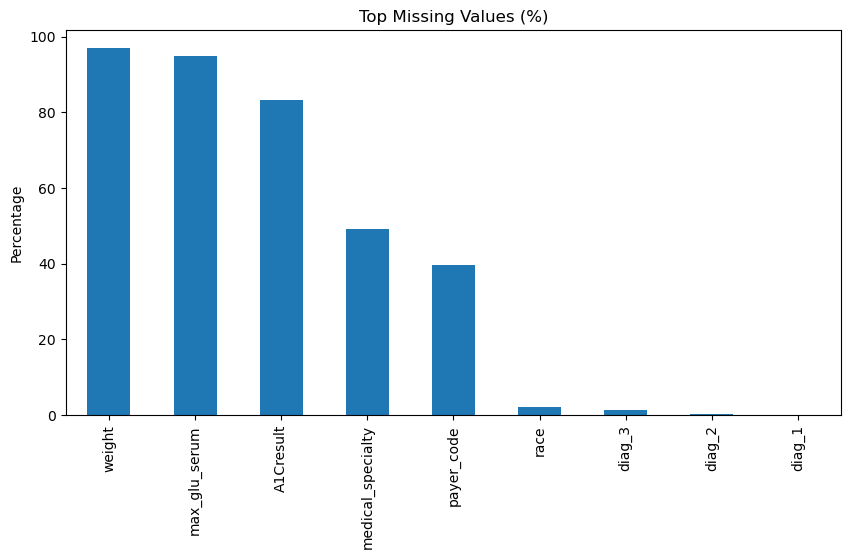

In [55]:
raw_df = pd.read_csv("diabetic_data.csv")
raw_df = raw_df.replace("?", np.nan)

missing = (raw_df.isnull().sum() / len(raw_df)) * 100
missing = missing[missing > 0].sort_values(ascending=False).head(10)

missing.plot(kind="bar", figsize=(10, 5))
plt.title("Top Missing Values (%)")
plt.ylabel("Percentage")
plt.show()

In [12]:
df = df.replace("?", np.nan)

In [13]:
missing = df.isnull().sum().sort_values(ascending=False)

missing[missing > 0]

weight               98569
max_glu_serum        96420
A1Cresult            84748
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
dtype: int64

In [14]:
#Create Target Variable

In [15]:
df["target"] = df["readmitted"].apply(
    lambda x: 1 if x == "<30" else 0
)

df["target"].value_counts()

target
0    90409
1    11357
Name: count, dtype: int64

In [16]:
#Remove Unnecessary Columns

In [17]:
drop_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted"
]

df.drop(columns=drop_columns, inplace=True)

In [18]:
#Remove Columns with Excessive Missing Values

In [19]:
missing_percent = (df.isnull().sum() / len(df)) * 100

columns_to_drop = missing_percent[
    missing_percent > 40
].index

print(columns_to_drop.tolist())

['weight', 'medical_specialty', 'max_glu_serum', 'A1Cresult']


In [20]:
df.drop(columns=columns_to_drop, inplace=True)

In [21]:
#Fill Remaining Missing Values

In [22]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [23]:
#Separate Features and Target

In [24]:
X = df.drop("target", axis=1)

y = df["target"]

In [25]:
#Encode Categorical Features

In [26]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [27]:
#Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
#Handle Class Imbalance

In [30]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [31]:
#Scale Features

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

In [33]:
#Train Random Forest Model

In [34]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train_smote)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
#Make Predictions

In [36]:
y_pred = rf.predict(X_test_scaled)

y_prob = rf.predict_proba(X_test_scaled)[:, 1]

In [37]:
#Evaluate Model

In [38]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

print(classification_report(y_test, y_pred))

Accuracy: 0.882430971799155
ROC-AUC Score: 0.6047418999231319
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.26      0.03      0.05      2271

    accuracy                           0.88     20354
   macro avg       0.58      0.51      0.50     20354
weighted avg       0.82      0.88      0.84     20354



In [39]:
#Confusion Matrix

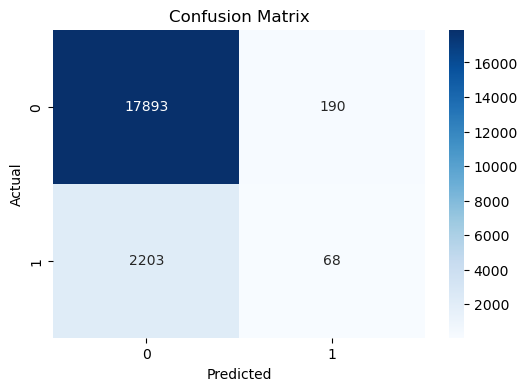

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [41]:
#Feature Importance

In [42]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
4,num_lab_procedures,0.029981
21,age_[50-60),0.029458
6,num_medications,0.028091
22,age_[60-70),0.027002
2330,insulin_No,0.026995
23,age_[70-80),0.025063
2331,insulin_Steady,0.022863
3,time_in_hospital,0.021957
2293,metformin_Steady,0.021043
2340,change_No,0.020660


In [43]:
#Plot Feature Importance

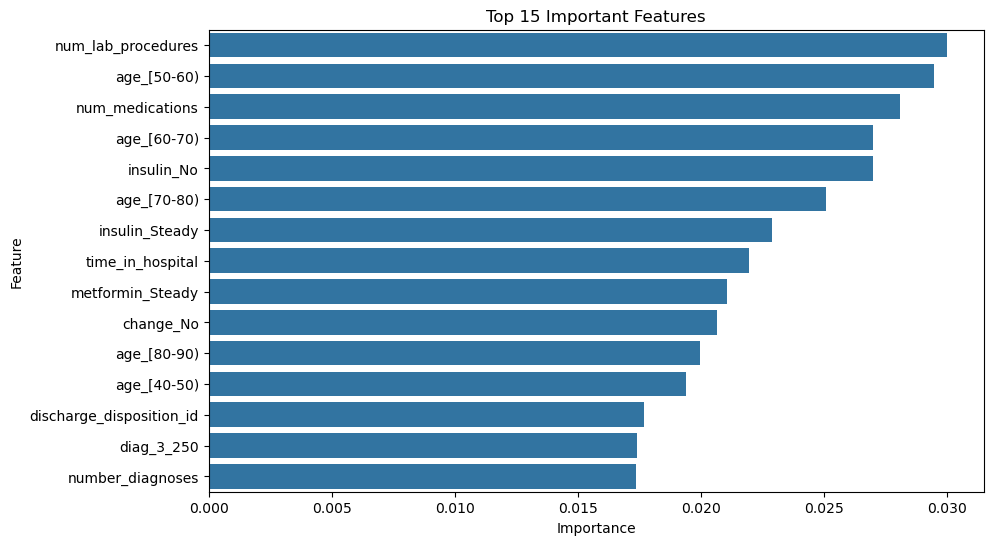

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

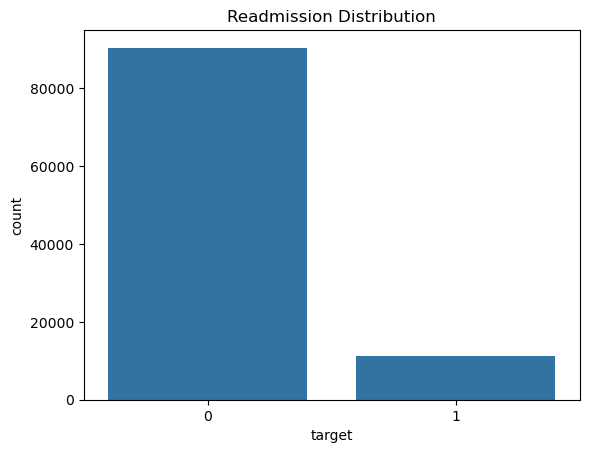

In [49]:
sns.countplot(x="target", data=df)
plt.title("Readmission Distribution")
plt.show()

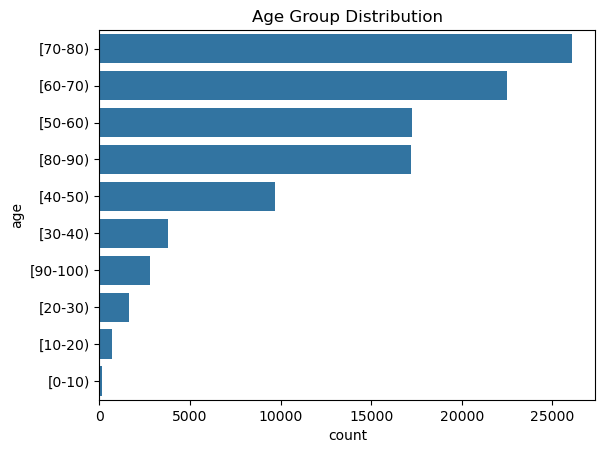

In [51]:
sns.countplot(y="age", data=df, order=df["age"].value_counts().index)
plt.title("Age Group Distribution")
plt.show()

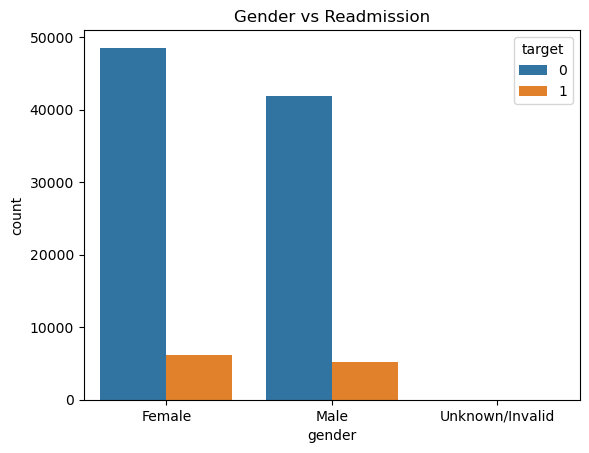

In [52]:
sns.countplot(x="gender", hue="target", data=df)
plt.title("Gender vs Readmission")
plt.show()

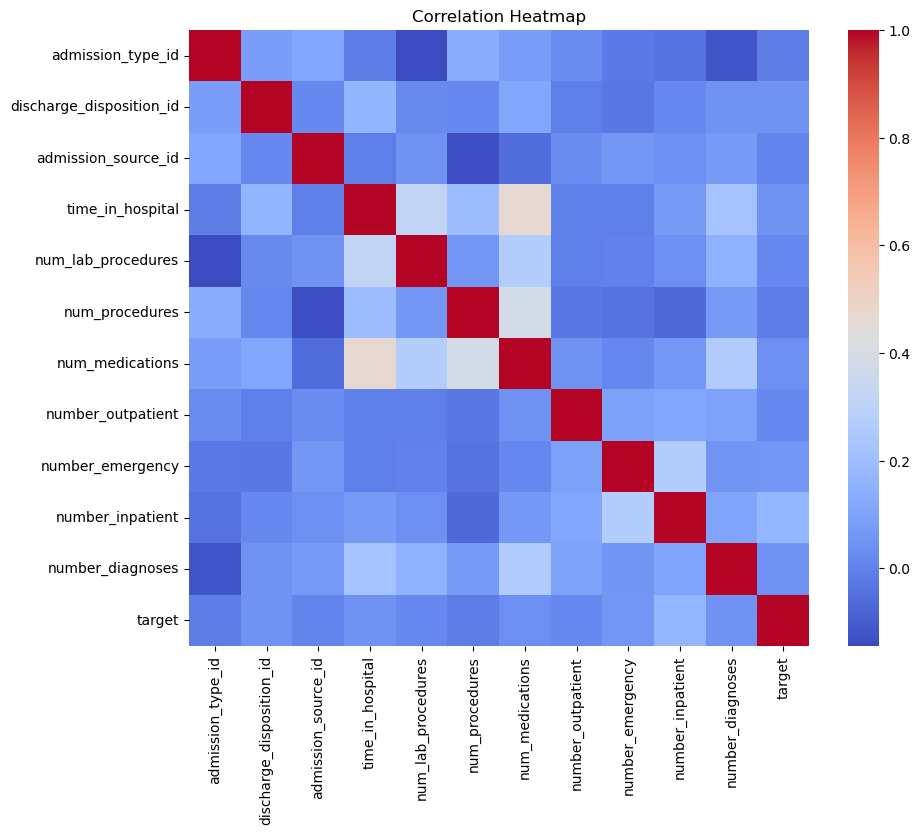

In [53]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [56]:
#save model

In [57]:
import joblib

joblib.dump(rf, "models/diabetes_readmission_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']